In [38]:
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.jplhorizons import Horizons
from lamberthub import gooding1990


AU_KM = 149_597_870.7
DAY_S = 86_400.0

MU_SUN = 2.959122082855911e-4 # AU^3 / day^2


@dataclass(frozen=True)
class StateVector:
    r: np.ndarray  # position [AU], shape=(3,)
    v: np.ndarray  # velocity [AU/day], shape=(3,)


@dataclass(frozen=True)
class TransferResult:
    v_dep: np.ndarray  # heliocentric departure velocity [AU/day]
    v_arr: np.ndarray  # heliocentric arrival velocity [AU/day]
    vinf_dep: float    # Earth-relative departure v-infinity [km/s]
    vinf_arr: float    # AA29-relative arrival v-infinity [km/s]
    c3: float          # Earth departure C3 [km^2/s^2]
    tof_days: float    # flight time [day]

In [39]:
epochs = {
    "start": "2090-01-01",
    "stop": "2110-01-01",
    "step": "1d",
}

earth_hor = Horizons(
    id="399",             # Earth center
    location="@sun",
    epochs=epochs,
)
earth_vec = earth_hor.vectors(refplane="ecliptic")

aa29_hor = Horizons(
    id="2002 AA29",
    id_type="smallbody",
    location="@sun",
    epochs=epochs,
)
aa29_vec = aa29_hor.vectors(refplane="ecliptic")

In [40]:
def au_per_day_to_km_per_s(value):
    return np.asarray(value) * AU_KM / DAY_S

def state_from_horizons(table, index):
    return StateVector(
        r=np.array(
            [table["x"][index], table["y"][index], table["z"][index]],
            dtype=float,
        ),
        v=np.array(
            [table["vx"][index], table["vy"][index], table["vz"][index]],
            dtype=float,
        ),
    )

def solve_lambert(
    earth_dep: StateVector,
    target_arr: StateVector,
    dep_jd: float,
    arr_jd: float,
    *,
    mu: float = MU_SUN,
) -> TransferResult:
    tof_days = float(arr_jd - dep_jd)

    v_sc_departure, v_sc_arrival = gooding1990(
        mu,
        earth_dep.r,
        target_arr.r,
        tof_days,
        M=0,
        prograde=True,
        low_path=True,
    )

    vinf_dep_au_day = np.linalg.norm(v_sc_departure - earth_dep.v)
    vinf_arr_au_day = np.linalg.norm(v_sc_arrival - target_arr.v)

    vinf_dep_km_s = float(au_per_day_to_km_per_s(vinf_dep_au_day))
    vinf_arr_km_s = float(au_per_day_to_km_per_s(vinf_arr_au_day))

    return TransferResult(
        v_dep=v_sc_departure,
        v_arr=v_sc_arrival,
        vinf_dep=vinf_dep_km_s,
        vinf_arr=vinf_arr_km_s,
        c3=vinf_dep_km_s**2,
        tof_days=tof_days,
    )

In [41]:
DEP_START_INDEX = 0
DEP_STOP_INDEX = 9 * 365 # 2027-01-01 ~ 2035

TOF_MIN_DAYS = 30
TOF_MAX_DAYS = 730

DATE_STEP_DAYS = 5
TOF_STEP_DAYS = 5

results = []

for dep_index in range(
    DEP_START_INDEX,
    DEP_STOP_INDEX + 1,
    DATE_STEP_DAYS,
):
    for tof_days in range(
        TOF_MIN_DAYS,
        TOF_MAX_DAYS + 1,
        TOF_STEP_DAYS,
    ):
        arr_index = dep_index + tof_days

        if arr_index >= len(aa29_vec):
            continue

        try:
            result = solve_lambert(
                state_from_horizons(earth_vec, dep_index),
                state_from_horizons(aa29_vec, arr_index),
                earth_vec["datetime_jd"][dep_index],
                aa29_vec["datetime_jd"][arr_index],
            )
        except ValueError:
            continue

        results.append({
            "dep_jd": earth_vec["datetime_jd"][dep_index],
            "arr_jd": aa29_vec["datetime_jd"][arr_index],
            "tof_days": result.tof_days,
            "c3_km2_s2": result.c3,
            "vinf_dep_km_s": result.vinf_dep,
            "vinf_arr_km_s": result.vinf_arr,
            "revolutions": 0,
        })

results_df = pd.DataFrame(results)
results_df.to_csv(
    "aa29_lambert_m0_coarse.csv",
    index=False,
)

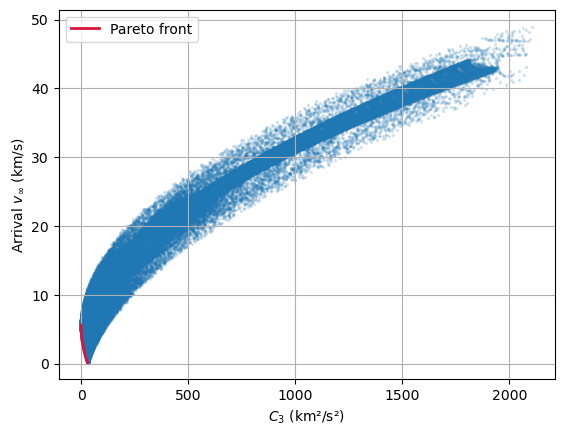

In [42]:
def get_pareto_front(df):
    df = df.sort_values("c3_km2_s2")

    best_vinf_arr = np.inf
    pareto_indices = []

    for index, row in df.iterrows():
        if row["vinf_arr_km_s"] < best_vinf_arr:
            pareto_indices.append(index)
            best_vinf_arr = row["vinf_arr_km_s"]

    return df.loc[pareto_indices]


pareto_df = get_pareto_front(results_df)

plt.scatter(
    results_df["c3_km2_s2"],
    results_df["vinf_arr_km_s"],
    s=2,
    alpha=0.15,
)

plt.plot(
    pareto_df["c3_km2_s2"],
    pareto_df["vinf_arr_km_s"],
    color="crimson",
    linewidth=2,
    label="Pareto front",
)

plt.xlabel(r"$C_3$ (km²/s²)")
plt.ylabel(r"Arrival $v_\infty$ (km/s)")
plt.grid()
plt.legend()
plt.show()

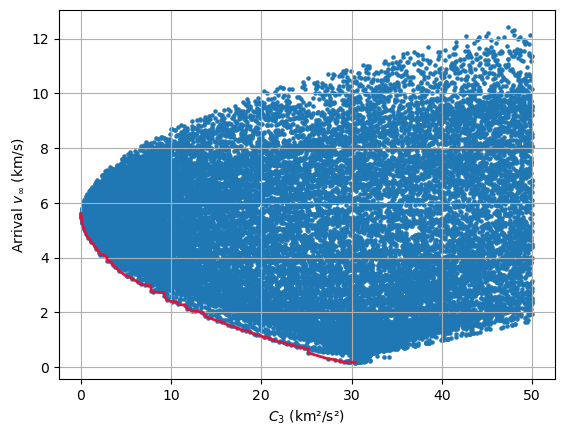

In [43]:
low_c3 = results_df.query("c3_km2_s2 <= 50")
pareto_df = get_pareto_front(low_c3)

plt.scatter(
    low_c3["c3_km2_s2"],
    low_c3["vinf_arr_km_s"],
    s=5,
)

plt.plot(
    pareto_df["c3_km2_s2"],
    pareto_df["vinf_arr_km_s"],
    color="crimson",
    linewidth=2,
    label="Pareto front",
)

plt.xlabel(r"$C_3$ (km²/s²)")
plt.ylabel(r"Arrival $v_\infty$ (km/s)")
plt.grid()
plt.show()

In [44]:
front_10_20 = pareto_df[
    pareto_df["c3_km2_s2"].between(10, 20)
].copy()

print(
    front_10_20[
        [
            "dep_jd",
            "arr_jd",
            "tof_days",
            "c3_km2_s2",
            "vinf_dep_km_s",
            "vinf_arr_km_s",
        ]
    ].sort_values("c3_km2_s2")
)

          dep_jd     arr_jd  tof_days  c3_km2_s2  vinf_dep_km_s  vinf_arr_km_s
77302  2487157.5  2487357.5     200.0  10.096126       3.177440       2.391791
77718  2487172.5  2487337.5     165.0  10.562216       3.249956       2.388447
67009  2486792.5  2486992.5     200.0  10.820979       3.289526       2.293034
87457  2487517.5  2487732.5     215.0  11.580169       3.402965       2.264686
88011  2487537.5  2487702.5     165.0  11.655687       3.414043       2.233488
67286  2486802.5  2486977.5     175.0  11.818591       3.437818       2.132670
77579  2487167.5  2487342.5     175.0  12.373162       3.517551       2.046354
67424  2486807.5  2486967.5     160.0  13.348565       3.653569       2.021687
77717  2487172.5  2487332.5     160.0  13.584913       3.685772       1.983614
87596  2487522.5  2487727.5     205.0  13.739698       3.706710       1.874093
87872  2487532.5  2487707.5     175.0  14.095025       3.754334       1.811528
77303  2487157.5  2487362.5     205.0  15.084799    

In [45]:
for c3_target in [10, 15, 20]:
    candidate = pareto_df.loc[
        (pareto_df["c3_km2_s2"] - c3_target).abs().idxmin()
    ]

    print(
        f"\nC3 ≈ {c3_target}"
        f"\nDeparture JD : {candidate['dep_jd']}"
        f"\nArrival JD   : {candidate['arr_jd']}"
        f"\nTOF          : {candidate['tof_days']:.0f} days"
        f"\nC3           : {candidate['c3_km2_s2']:.3f} km²/s²"
        f"\nArrival v∞   : {candidate['vinf_arr_km_s']:.3f} km/s"
    )


C3 ≈ 10
Departure JD : 2487157.5
Arrival JD   : 2487357.5
TOF          : 200 days
C3           : 10.096 km²/s²
Arrival v∞   : 2.392 km/s

C3 ≈ 15
Departure JD : 2487157.5
Arrival JD   : 2487362.5
TOF          : 205 days
C3           : 15.085 km²/s²
Arrival v∞   : 1.701 km/s

C3 ≈ 20
Departure JD : 2487522.5
Arrival JD   : 2487737.5
TOF          : 215 days
C3           : 19.788 km²/s²
Arrival v∞   : 1.171 km/s


In [49]:
dep_center = 2487522.5
arr_center = 2487737.5

refined_results = []

for dep_jd in np.arange(dep_center - 20, dep_center + 21, 1):
    for arr_jd in np.arange(arr_center - 20, arr_center + 21, 1):
        if arr_jd <= dep_jd:
            continue

        dep_index = np.argmin(
            np.abs(earth_vec["datetime_jd"] - dep_jd)
        )
        arr_index = np.argmin(
            np.abs(aa29_vec["datetime_jd"] - arr_jd)
        )

        result = solve_lambert(
            state_from_horizons(earth_vec, dep_index),
            state_from_horizons(aa29_vec, arr_index),
            earth_vec["datetime_jd"][dep_index],
            aa29_vec["datetime_jd"][arr_index],
        )

        refined_results.append({
            "dep_jd": earth_vec["datetime_jd"][dep_index],
            "arr_jd": aa29_vec["datetime_jd"][arr_index],
            "tof_days": result.tof_days,
            "c3_km2_s2": result.c3,
            "vinf_arr_km_s": result.vinf_arr,
        })

refined_df = pd.DataFrame(refined_results)

reference = refined_df.query(
    "c3_km2_s2 <= 20"
).nsmallest(
    1,
    "vinf_arr_km_s",
)

print(reference)

        dep_jd     arr_jd  tof_days  c3_km2_s2  vinf_arr_km_s
989  2487526.5  2487722.5     196.0   19.94976       1.065905


In [51]:
candidate = refined_df.loc[989]

dep_jd = candidate["dep_jd"]
arr_jd = candidate["arr_jd"]

dep_index = np.argmin(
    np.abs(earth_vec["datetime_jd"] - dep_jd)
)

arr_index = np.argmin(
    np.abs(aa29_vec["datetime_jd"] - arr_jd)
)

earth_dep = state_from_horizons(
    earth_vec,
    dep_index,
)

aa29_arr = state_from_horizons(
    aa29_vec,
    arr_index,
)

result = solve_lambert(
    earth_dep,
    aa29_arr,
    dep_jd,
    arr_jd,
)

r_dep = earth_dep.r       # 지구의 태양 중심 출발 위치 [AU]
v_earth = earth_dep.v     # 지구의 태양 중심 출발 속도 [AU/day]

v_sc_dep = result.v_dep   # 탐사선의 태양 중심 출발 속도 [AU/day]
v_sc_arr = result.v_arr   # 탐사선의 태양 중심 도착 속도 [AU/day]

In [52]:
from scipy.integrate import solve_ivp


def propagate_sun_2body(r0, v0, dt_days, mu=MU_SUN):
    """AU, AU/day 단위의 태양 2체 전파."""
    y0 = np.hstack((r0, v0))

    def rhs(_, y):
        r = y[:3]
        v = y[3:]
        a = -mu * r / np.linalg.norm(r)**3

        return np.hstack((v, a))

    solution = solve_ivp(
        rhs,
        (0.0, dt_days),
        y0,
        rtol=1e-12,
        atol=1e-14,
    )

    return solution.y[:3, -1], solution.y[3:, -1]

r_sc_start, v_sc_start = propagate_sun_2body(
    r0=r_dep,
    v0=v_sc_dep,
    dt_days=15.0,
)

print(r_sc_start)
print(v_sc_start)

[ 0.4835385  -0.89729962 -0.03789595]
[ 0.0148363   0.0078598  -0.00248766]
